# Phase 1 — Exploratory Data Analysis (EDA)


---
## Step 1 — Import Libraries

In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', 35)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style('whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

print('Libraries loaded successfully!')

Libraries loaded successfully!


---
## Step 2 — Load & Inspect the Dataset

In [2]:
# Load the dataset
# Update the path below if your file is in a different location
df = pd.read_csv('creditcard.csv')

print('Dataset loaded!')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')

Dataset loaded!
Shape: 284,807 rows x 31 columns


In [3]:
# Preview first 5 rows
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,-0.2265,0.1782,0.5078,-0.2879,-0.6314,-1.0596,-0.6841,1.9658,-1.2326,-0.2080,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,-0.8228,0.5382,1.3459,-1.1197,0.1751,-0.4514,-0.2370,-0.0382,0.8035,0.4085,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


In [4]:
# Column data types
print('Column Data Types:')
print('-' * 35)
print(df.dtypes)

Column Data Types:
-----------------------------------
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


In [5]:
# Statistical summary
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000
mean,94813.8596,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,-0.0000,88.3496,0.0017
std,47488.1460,1.9587,1.6513,1.5163,1.4159,1.3802,1.3323,1.2371,1.1944,1.0986,1.0888,1.0207,0.9992,0.9953,0.9586,0.9153,0.8763,0.8493,0.8382,0.8140,0.7709,0.7345,0.7257,0.6245,0.6056,0.5213,0.4822,0.4036,0.3301,250.1201,0.0415
min,0.0000,-56.4075,-72.7157,-48.3256,-5.6832,-113.7433,-26.1605,-43.5572,-73.2167,-13.4341,-24.5883,-4.7975,-18.6837,-5.7919,-19.2143,-4.4989,-14.1299,-25.1628,-9.4987,-7.2135,-54.4977,-34.8304,-10.9331,-44.8077,-2.8366,-10.2954,-2.6046,-22.5657,-15.4301,0.0000,0.0000
25%,54201.5000,-0.9204,-0.5985,-0.8904,-0.8486,-0.6916,-0.7683,-0.5541,-0.2086,-0.6431,-0.5354,-0.7625,-0.4056,-0.6485,-0.4256,-0.5829,-0.4680,-0.4837,-0.4988,-0.4563,-0.2117,-0.2284,-0.5424,-0.1618,-0.3546,-0.3171,-0.3270,-0.0708,-0.0530,5.6000,0.0000
50%,84692.0000,0.0181,0.0655,0.1798,-0.0198,-0.0543,-0.2742,0.0401,0.0224,-0.0514,-0.0929,-0.0328,0.1400,-0.0136,0.0506,0.0481,0.0664,-0.0657,-0.0036,0.0037,-0.0625,-0.0295,0.0068,-0.0112,0.0410,0.0166,-0.0521,0.0013,0.0112,22.0000,0.0000
75%,139320.5000,1.3156,0.8037,1.0272,0.7433,0.6119,0.3986,0.5704,0.3273,0.5971,0.4539,0.7396,0.6182,0.6625,0.4931,0.6488,0.5233,0.3997,0.5008,0.4589,0.1330,0.1864,0.5286,0.1476,0.4395,0.3507,0.2410,0.0910,0.0783,77.1650,0.0000
max,172792.0000,2.4549,22.0577,9.3826,16.8753,34.8017,73.3016,120.5895,20.0072,15.5950,23.7451,12.0189,7.8484,7.1269,10.5268,8.8777,17.3151,9.2535,5.0411,5.5920,39.4209,27.2028,10.5031,22.5284,4.5845,7.5196,3.5173,31.6122,33.8478,25691.1600,1.0000


---
## Step 3 — Missing Values & Data Quality Check

In [6]:
# Check for missing values
missing = df.isnull().sum()
total_missing = missing.sum()

print('=' * 40)
print(f'Total Missing Values : {total_missing}')
print(f'Total Rows           : {len(df):,}')
print(f'Total Columns        : {df.shape[1]}')
print(f'Duplicate Rows       : {df.duplicated().sum():,}')
print('=' * 40)

if total_missing == 0:
    print('✓ No missing values found. Dataset is clean!')
else:
    print('Missing values per column:')
    print(missing[missing > 0])

Total Missing Values : 0
Total Rows           : 284,807
Total Columns        : 31
Duplicate Rows       : 1,081
✓ No missing values found. Dataset is clean!


---
## Step 4 — Class Distribution (Imbalance Analysis)

In [7]:
# Class distribution stats
class_counts = df['Class'].value_counts()
class_pct    = df['Class'].value_counts(normalize=True) * 100

print('Class Distribution:')
print('-' * 40)
print(f'Legitimate (0) : {class_counts[0]:>8,}  ({class_pct[0]:.4f}%)')
print(f'Fraud      (1) : {class_counts[1]:>8,}  ({class_pct[1]:.4f}%)')
print('-' * 40)
print(f'Imbalance ratio: 1 fraud for every {class_counts[0]//class_counts[1]:,} legitimate transactions')

Class Distribution:
----------------------------------------
Legitimate (0) :  284,315  (99.8273%)
Fraud      (1) :      492  (0.1727%)
----------------------------------------
Imbalance ratio: 1 fraud for every 577 legitimate transactions


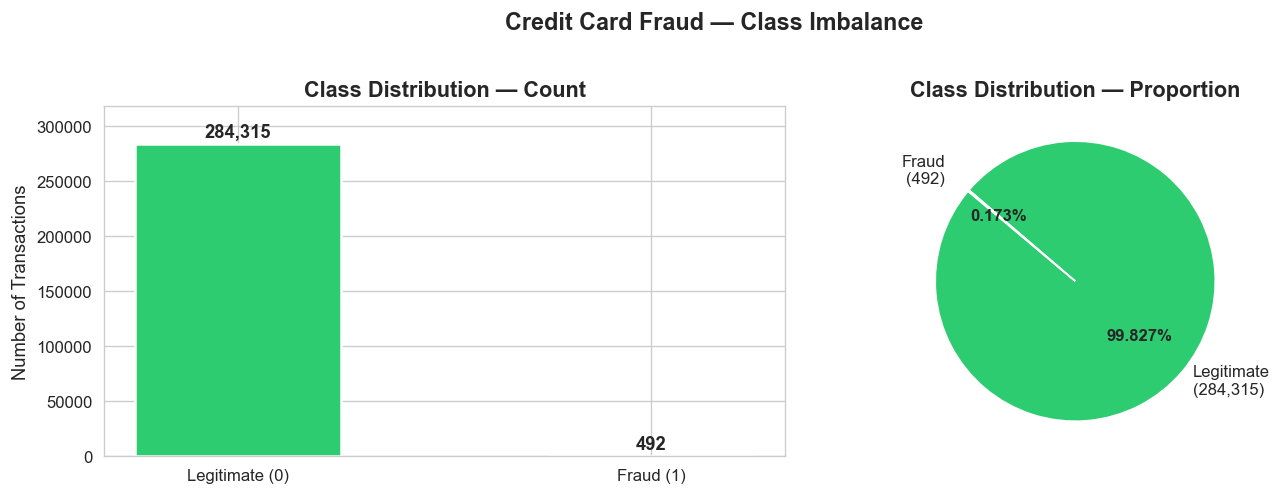

Plot saved: plot_01_class_distribution.png


In [8]:
# Visualize class imbalance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['#2ecc71', '#e74c3c']
labels = ['Legitimate\n(284,315)', 'Fraud\n(492)']

# --- Bar chart ---
bars = axes[0].bar(['Legitimate (0)', 'Fraud (1)'],
                   class_counts.values,
                   color=colors, edgecolor='white', linewidth=1.5, width=0.5)
axes[0].set_title('Class Distribution — Count', fontweight='bold')
axes[0].set_ylabel('Number of Transactions')
for bar, count in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 2000,
                 f'{count:,}',
                 ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[0].set_ylim(0, class_counts[0] * 1.12)

# --- Pie chart ---
explode = (0, 0.12)
wedges, texts, autotexts = axes[1].pie(
    class_counts.values,
    labels=labels,
    colors=colors,
    autopct='%1.3f%%',
    explode=explode,
    startangle=140,
    textprops={'fontsize': 10}
)
for at in autotexts:
    at.set_fontweight('bold')
axes[1].set_title('Class Distribution — Proportion', fontweight='bold')

plt.suptitle('Credit Card Fraud — Class Imbalance', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_01_class_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print('Plot saved: plot_01_class_distribution.png')

---
## Step 5 — Transaction Amount Analysis

In [9]:
# Amount stats split by class
fraud_amt     = df[df['Class'] == 1]['Amount']
legit_amt     = df[df['Class'] == 0]['Amount']

print('Transaction Amount — Fraud vs Legitimate')
print('=' * 50)
stats = pd.DataFrame({
    'Legitimate': legit_amt.describe(),
    'Fraud'     : fraud_amt.describe()
})
print(stats.round(2))

print()
print(f'Max legitimate transaction : ${legit_amt.max():,.2f}')
print(f'Max fraud transaction      : ${fraud_amt.max():,.2f}')
print(f'Mean legitimate amount     : ${legit_amt.mean():.2f}')
print(f'Mean fraud amount          : ${fraud_amt.mean():.2f}')

Transaction Amount — Fraud vs Legitimate
       Legitimate     Fraud
count 284315.0000  492.0000
mean      88.2900  122.2100
std      250.1100  256.6800
min        0.0000    0.0000
25%        5.6500    1.0000
50%       22.0000    9.2500
75%       77.0500  105.8900
max    25691.1600 2125.8700

Max legitimate transaction : $25,691.16
Max fraud transaction      : $2,125.87
Mean legitimate amount     : $88.29
Mean fraud amount          : $122.21


C:\Users\Ritu\AppData\Local\Temp\ipykernel_4392\4101519881.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[2].boxplot(data_to_plot,


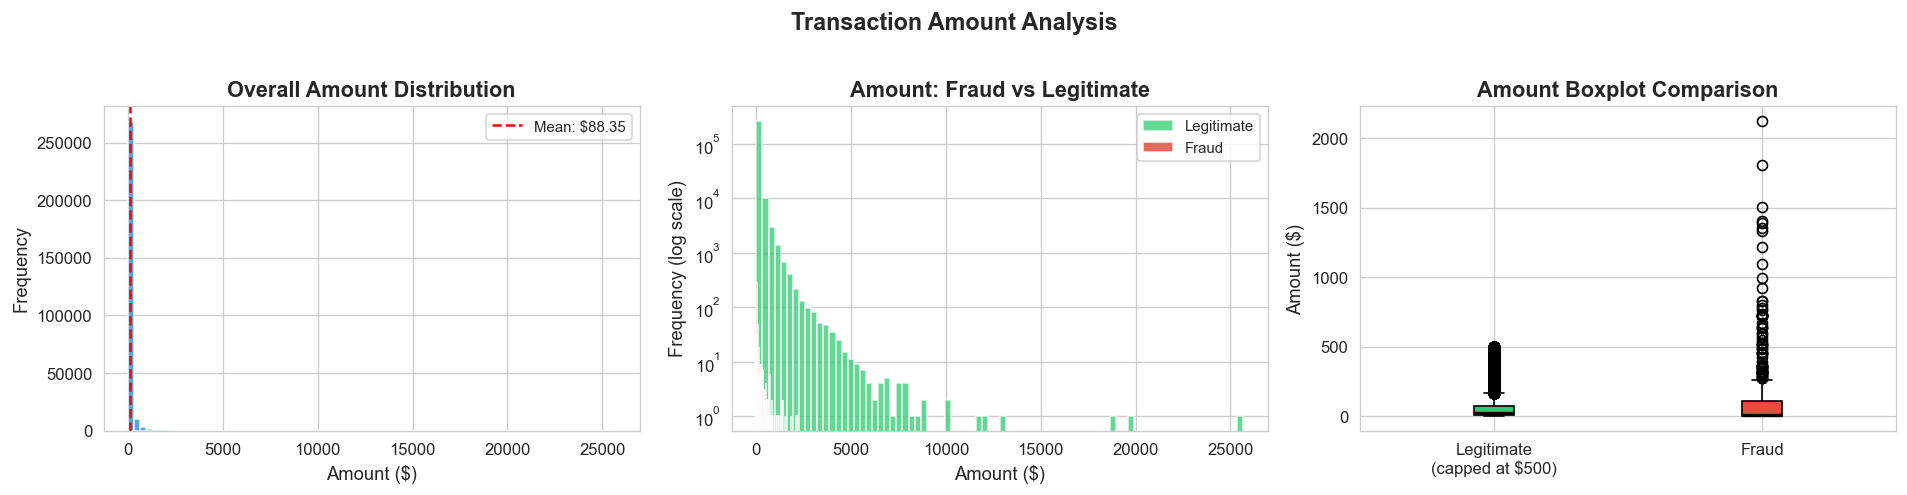

Plot saved: plot_02_amount_analysis.png


In [10]:
# Amount distribution plots
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# --- Overall distribution ---
axes[0].hist(df['Amount'], bins=80, color='#3498db', edgecolor='white', alpha=0.85)
axes[0].set_title('Overall Amount Distribution', fontweight='bold')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['Amount'].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: ${df["Amount"].mean():.2f}')
axes[0].legend(fontsize=9)

# --- Fraud vs Legitimate (log scale) ---
axes[1].hist(legit_amt, bins=80, alpha=0.75, color='#2ecc71', label='Legitimate', edgecolor='white')
axes[1].hist(fraud_amt, bins=80, alpha=0.85, color='#e74c3c', label='Fraud',      edgecolor='white')
axes[1].set_title('Amount: Fraud vs Legitimate', fontweight='bold')
axes[1].set_xlabel('Amount ($)')
axes[1].set_ylabel('Frequency (log scale)')
axes[1].set_yscale('log')
axes[1].legend(fontsize=9)

# --- Box plot ---
data_to_plot = [legit_amt[legit_amt < 500], fraud_amt]
bp = axes[2].boxplot(data_to_plot,
                     labels=['Legitimate\n(capped at $500)', 'Fraud'],
                     patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#e74c3c')
axes[2].set_title('Amount Boxplot Comparison', fontweight='bold')
axes[2].set_ylabel('Amount ($)')

plt.suptitle('Transaction Amount Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_02_amount_analysis.png', bbox_inches='tight', dpi=150)
plt.show()
print('Plot saved: plot_02_amount_analysis.png')

---
## Step 6 — Transaction Time Analysis

In [11]:
# Convert time to hours for readability
df['Hour'] = (df['Time'] / 3600).astype(int)

fraud_hours = df[df['Class'] == 1]['Hour']
legit_hours = df[df['Class'] == 0]['Hour']

print(f'Time range: {df["Time"].min():.0f}s to {df["Time"].max():.0f}s')
print(f'Approx. {df["Time"].max() / 3600:.1f} hours of transaction data (~2 days)')

Time range: 0s to 172792s
Approx. 48.0 hours of transaction data (~2 days)


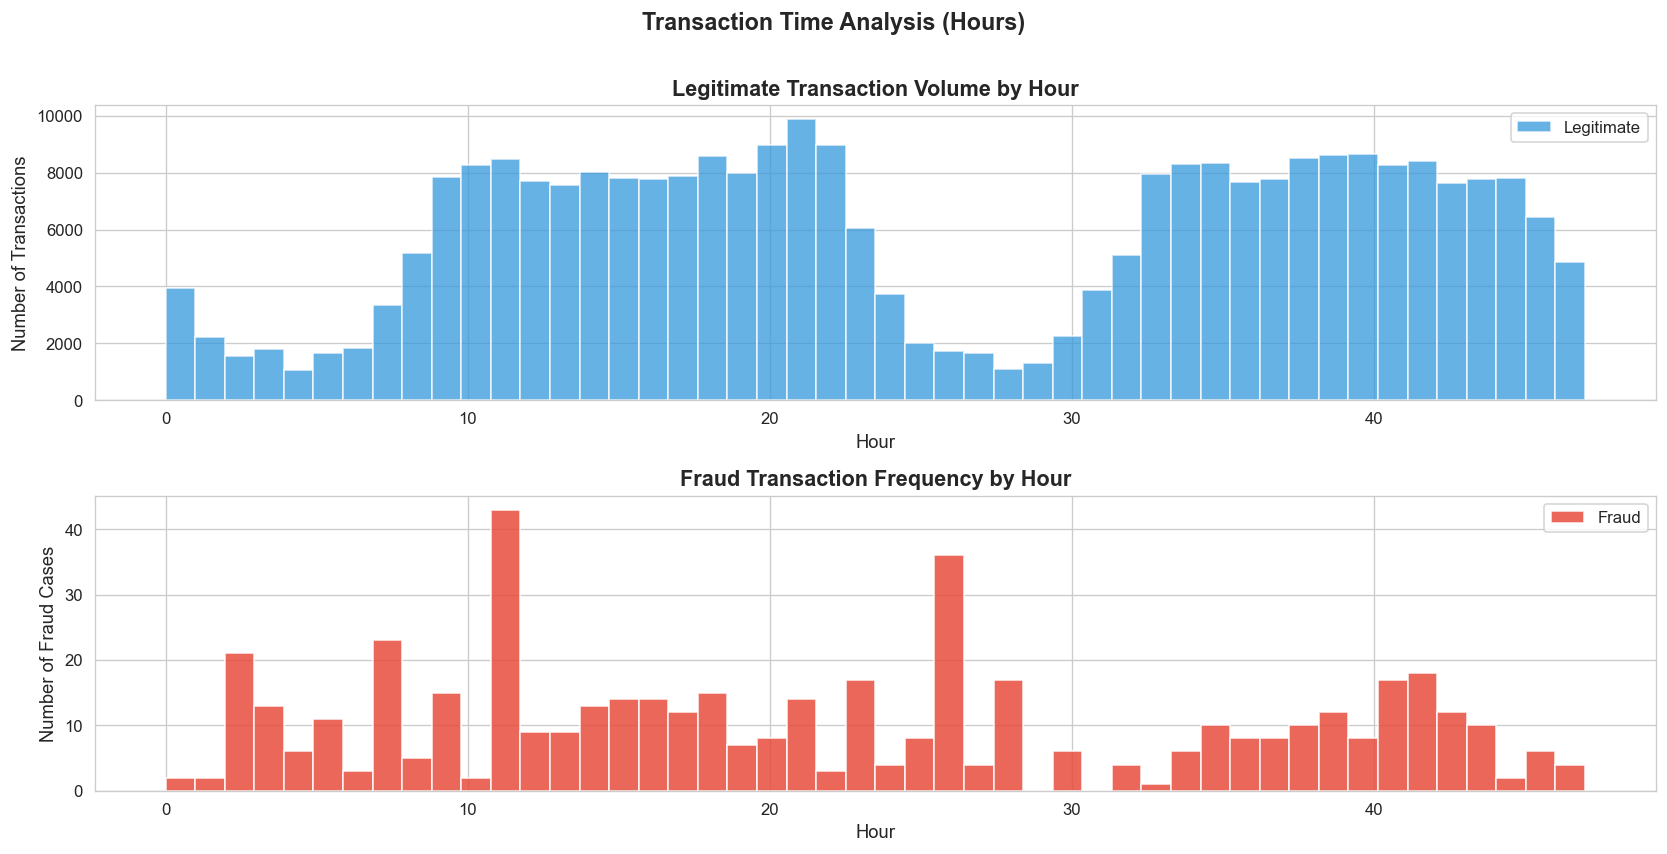

Plot saved: plot_03_time_analysis.png


In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# --- Transactions over time ---
axes[0].hist(legit_hours, bins=48, color='#3498db', alpha=0.75, label='Legitimate', edgecolor='white')
axes[0].set_title('Legitimate Transaction Volume by Hour', fontweight='bold')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Number of Transactions')
axes[0].legend()

# --- Fraud transactions over time ---
axes[1].hist(fraud_hours, bins=48, color='#e74c3c', alpha=0.85, label='Fraud', edgecolor='white')
axes[1].set_title('Fraud Transaction Frequency by Hour', fontweight='bold')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Number of Fraud Cases')
axes[1].legend()

plt.suptitle('Transaction Time Analysis (Hours)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_03_time_analysis.png', bbox_inches='tight', dpi=150)
plt.show()
print('Plot saved: plot_03_time_analysis.png')

# Clean up temporary column
df.drop('Hour', axis=1, inplace=True)

---
## Step 7 — Feature Correlation Heatmap

> V1–V28 are PCA-transformed (already decorrelated from each other).
> We look for correlation with the `Class` column to find the most predictive features.

In [13]:
# Correlation of each feature with Class
corr_with_class = df.corr()['Class'].drop('Class').sort_values()

print('Top 10 features most correlated with Fraud (Class=1):')
print('-' * 45)
print('Negative correlation (lower = more fraud-related):')
print(corr_with_class.head(10).round(4))
print()
print('Positive correlation (higher = more fraud-related):')
print(corr_with_class.tail(10).round(4))

Top 10 features most correlated with Fraud (Class=1):
---------------------------------------------
Negative correlation (lower = more fraud-related):
V17   -0.3265
V14   -0.3025
V12   -0.2606
V10   -0.2169
V16   -0.1965
V3    -0.1930
V7    -0.1873
V18   -0.1115
V1    -0.1013
V9    -0.0977
Name: Class, dtype: float64

Positive correlation (higher = more fraud-related):
Amount   0.0056
V28      0.0095
V27      0.0176
V8       0.0199
V20      0.0201
V19      0.0348
V21      0.0404
V2       0.0913
V4       0.1334
V11      0.1549
Name: Class, dtype: float64


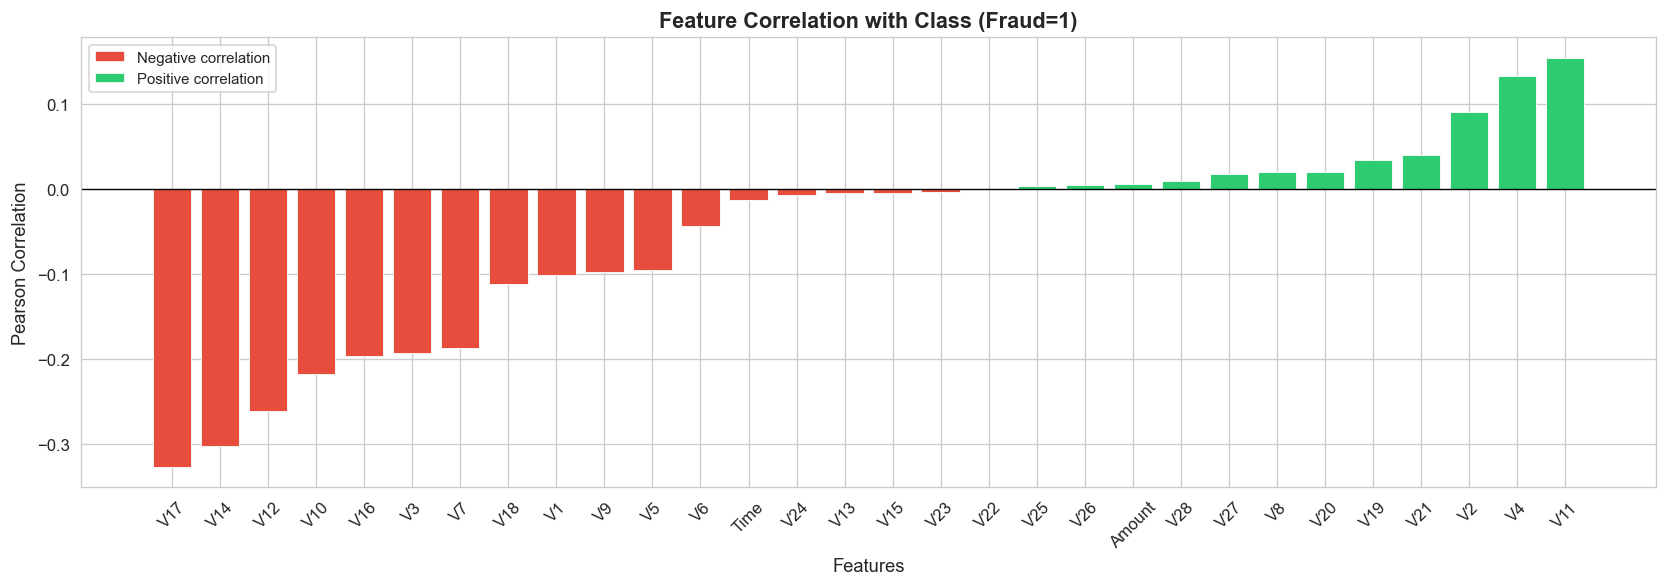

Plot saved: plot_04_feature_correlation_bar.png


In [14]:
# Bar chart of feature correlation with Class
fig, ax = plt.subplots(figsize=(14, 5))

colors_bar = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr_with_class.values]
ax.bar(corr_with_class.index, corr_with_class.values, color=colors_bar, edgecolor='white', linewidth=0.5)
ax.axhline(0, color='black', linewidth=0.8, linestyle='-')
ax.set_title('Feature Correlation with Class (Fraud=1)', fontweight='bold', fontsize=13)
ax.set_xlabel('Features')
ax.set_ylabel('Pearson Correlation')
ax.tick_params(axis='x', rotation=45)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Negative correlation'),
                   Patch(facecolor='#2ecc71', label='Positive correlation')]
ax.legend(handles=legend_elements, fontsize=9)

plt.tight_layout()
plt.savefig('plot_04_feature_correlation_bar.png', bbox_inches='tight', dpi=150)
plt.show()
print('Plot saved: plot_04_feature_correlation_bar.png')

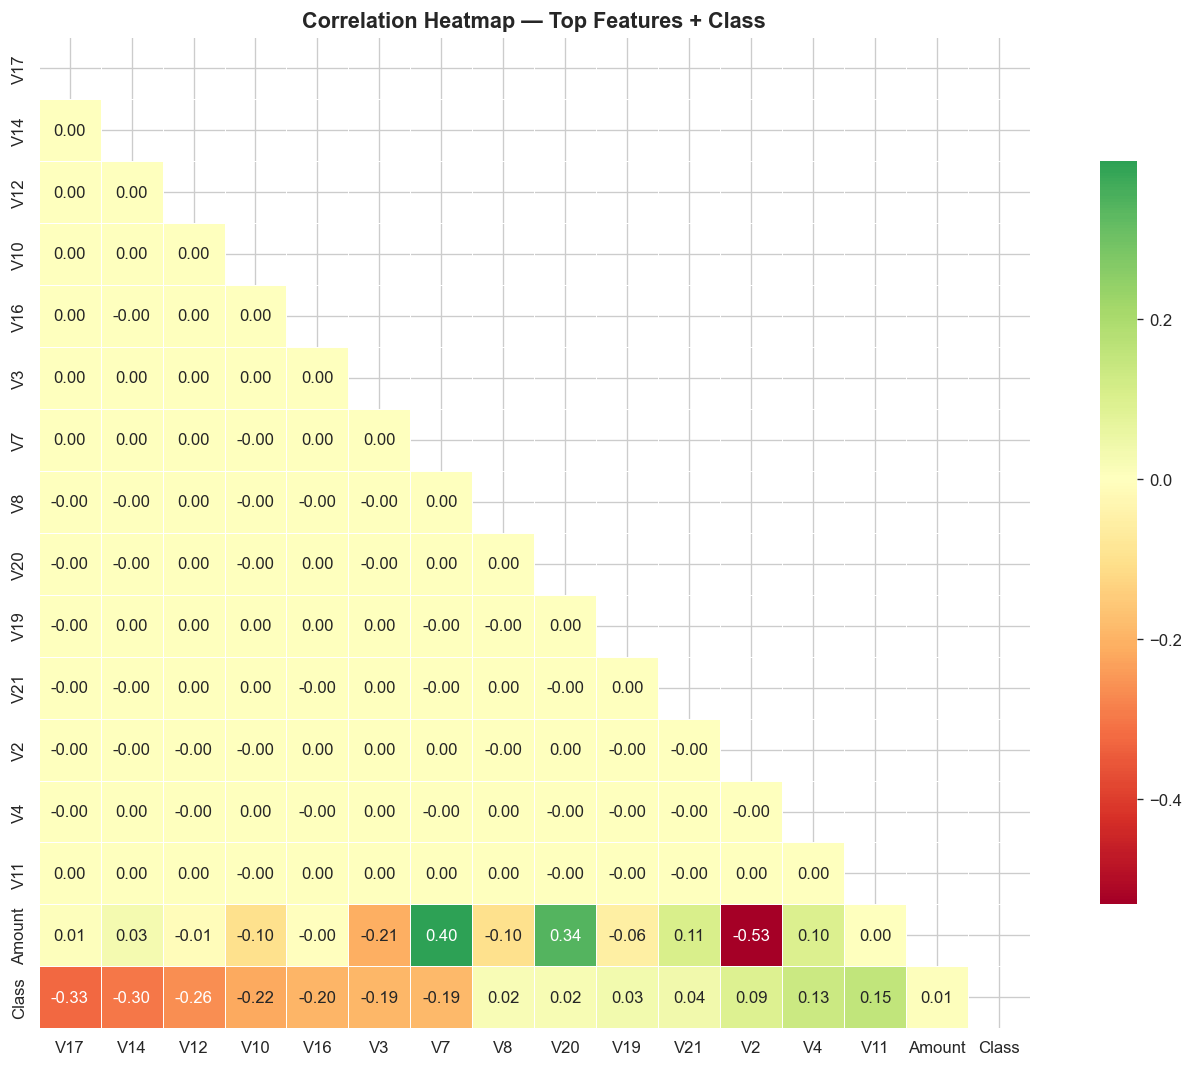

Plot saved: plot_05_correlation_heatmap.png


In [15]:
# Heatmap of top correlated features only (for readability)
top_features = list(corr_with_class.head(7).index) + list(corr_with_class.tail(7).index) + ['Amount', 'Class']
corr_matrix  = df[top_features].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Upper triangle mask
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.75},
    ax=ax
)
ax.set_title('Correlation Heatmap — Top Features + Class', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('plot_05_correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print('Plot saved: plot_05_correlation_heatmap.png')

---
## Step 8 — Fraud vs Non-Fraud Feature Distributions

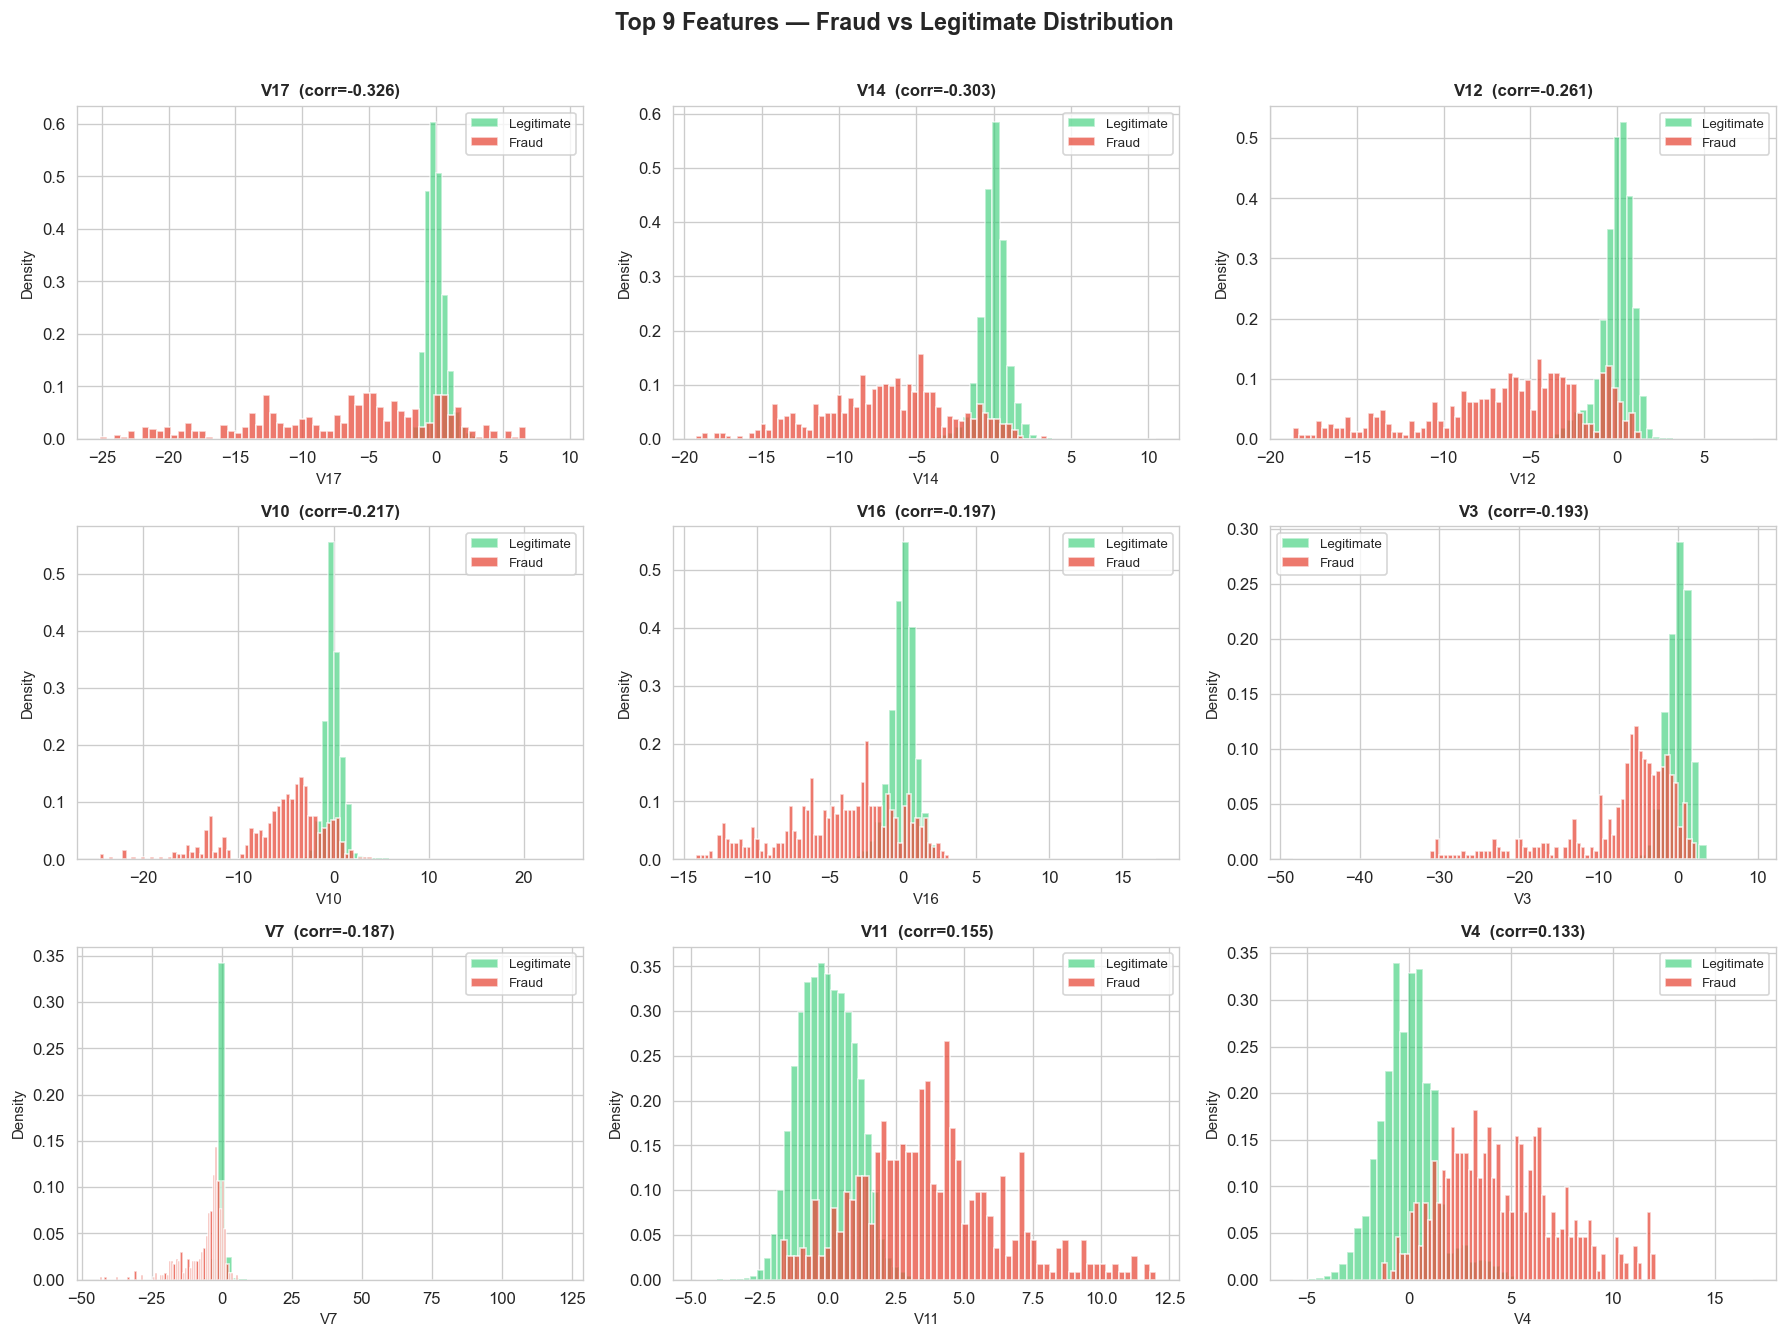

Plot saved: plot_06_top_feature_distributions.png


In [16]:
# Top 9 most discriminative features by absolute correlation
top9 = corr_with_class.abs().sort_values(ascending=False).head(9).index.tolist()

fraud = df[df['Class'] == 1]
legit = df[df['Class'] == 0]

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

for i, feat in enumerate(top9):
    axes[i].hist(legit[feat], bins=60, alpha=0.6, color='#2ecc71',
                 label='Legitimate', density=True, edgecolor='white')
    axes[i].hist(fraud[feat], bins=60, alpha=0.75, color='#e74c3c',
                 label='Fraud', density=True, edgecolor='white')
    axes[i].set_title(f'{feat}  (corr={corr_with_class[feat]:.3f})', fontweight='bold', fontsize=10)
    axes[i].set_xlabel(feat, fontsize=9)
    axes[i].set_ylabel('Density', fontsize=9)
    axes[i].legend(fontsize=8)

plt.suptitle('Top 9 Features — Fraud vs Legitimate Distribution', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_06_top_feature_distributions.png', bbox_inches='tight', dpi=150)
plt.show()
print('Plot saved: plot_06_top_feature_distributions.png')

---
## Step 9 — Violin Plots for Top Features

C:\Users\Ritu\AppData\Local\Temp\ipykernel_4392\2262106479.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\Ritu\AppData\Local\Temp\ipykernel_4392\2262106479.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Legitimate (0)', 'Fraud (1)'])
C:\Users\Ritu\AppData\Local\Temp\ipykernel_4392\2262106479.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\Ritu\AppData\Local\Temp\ipykernel_4392\2262106479.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xtickla

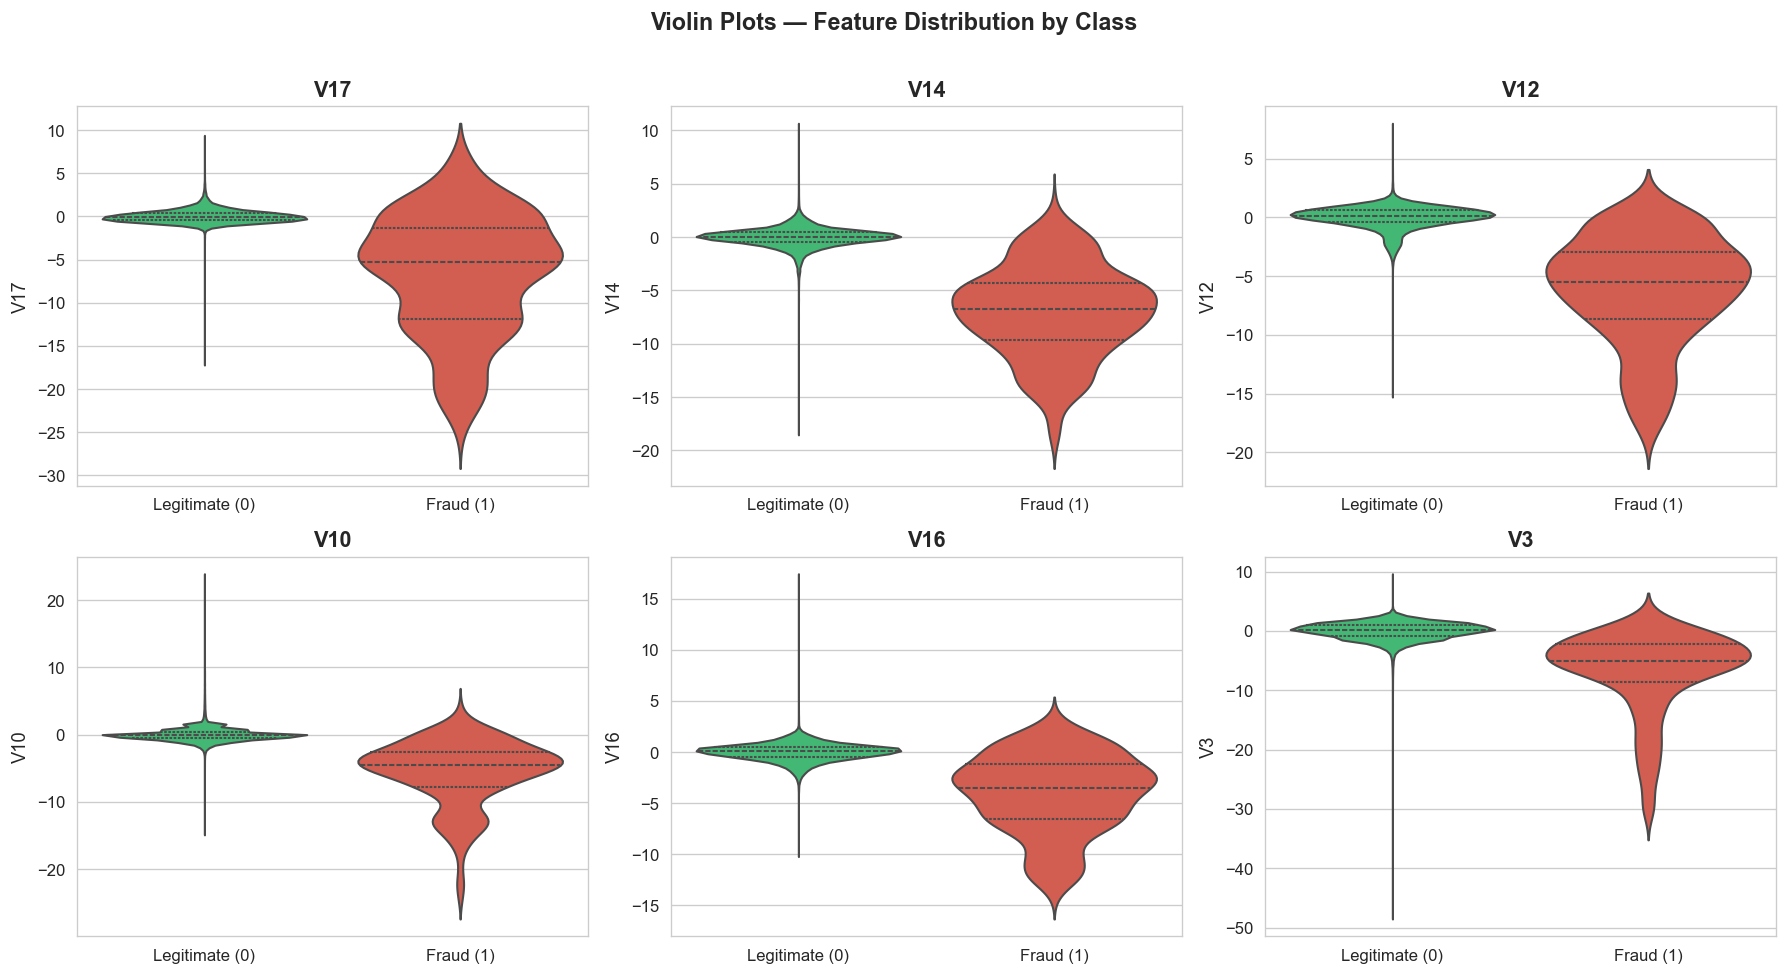

Plot saved: plot_07_violin_plots.png


In [18]:
# Violin plots — top 6 features
top6 = corr_with_class.abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(top6):
    sns.violinplot(
        x='Class', y=feat,
        data=df,
        palette=['#2ecc71', '#e74c3c'],
        inner='quartile',
        ax=axes[i]
    )
    axes[i].set_title(f'{feat}', fontweight='bold')
    axes[i].set_xticklabels(['Legitimate (0)', 'Fraud (1)'])
    axes[i].set_xlabel('')

plt.suptitle('Violin Plots — Feature Distribution by Class', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_07_violin_plots.png', bbox_inches='tight', dpi=150)
plt.show()
print('Plot saved: plot_07_violin_plots.png')

---
## Step 10 — Fraud Transaction Amount Deep Dive

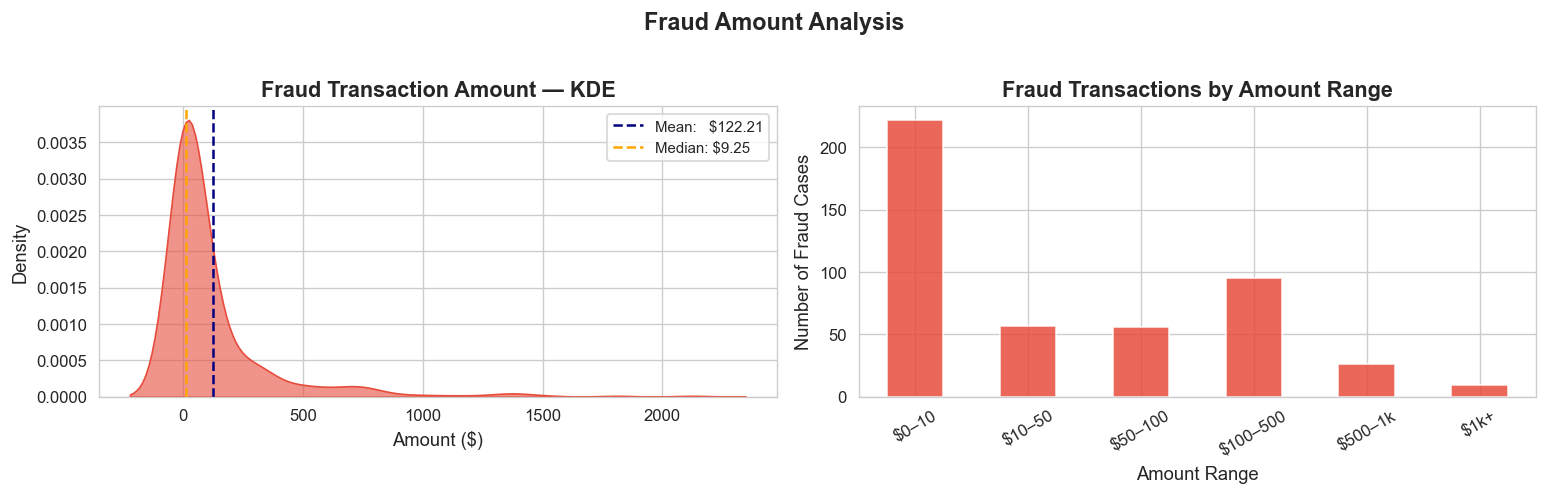

Plot saved: plot_08_fraud_amount_deepdive.png


In [19]:
fraud_amounts = df[df['Class'] == 1]['Amount']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- KDE plot ---
sns.kdeplot(fraud_amounts, ax=axes[0], fill=True, color='#e74c3c', alpha=0.6)
axes[0].axvline(fraud_amounts.mean(),   color='navy',   linestyle='--', label=f'Mean:   ${fraud_amounts.mean():.2f}')
axes[0].axvline(fraud_amounts.median(), color='orange', linestyle='--', label=f'Median: ${fraud_amounts.median():.2f}')
axes[0].set_title('Fraud Transaction Amount — KDE', fontweight='bold')
axes[0].set_xlabel('Amount ($)')
axes[0].legend(fontsize=9)

# --- Fraud amount bins ---
bins = [0, 10, 50, 100, 500, 1000, 3000]
labels_bins = ['$0–10', '$10–50', '$50–100', '$100–500', '$500–1k', '$1k+']
fraud_binned = pd.cut(fraud_amounts, bins=bins, labels=labels_bins)
fraud_binned.value_counts().sort_index().plot(kind='bar', ax=axes[1],
                                               color='#e74c3c', edgecolor='white', alpha=0.85)
axes[1].set_title('Fraud Transactions by Amount Range', fontweight='bold')
axes[1].set_xlabel('Amount Range')
axes[1].set_ylabel('Number of Fraud Cases')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Fraud Amount Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_08_fraud_amount_deepdive.png', bbox_inches='tight', dpi=150)
plt.show()
print('Plot saved: plot_08_fraud_amount_deepdive.png')

---
## Step 11 — EDA Summary & Key Observations

In [20]:
# Final summary printout
fraud   = df[df['Class'] == 1]
legit   = df[df['Class'] == 0]
top_neg = corr_with_class.head(5).index.tolist()
top_pos = corr_with_class.tail(5).index.tolist()

print('=' * 60)
print('          EDA SUMMARY — KEY OBSERVATIONS')
print('=' * 60)

print(f"""
DATASET OVERVIEW
  Total transactions    : {len(df):,}
  Legitimate (Class=0)  : {len(legit):,} ({len(legit)/len(df)*100:.2f}%)
  Fraud (Class=1)       : {len(fraud):,}   ({len(fraud)/len(df)*100:.4f}%)
  Missing values        : 0 (clean dataset)
  Features              : 30 (Time, V1-V28, Amount) + 1 target (Class)

CLASS IMBALANCE
  Ratio                 : 1 fraud per {len(legit)//len(fraud):,} legitimate
  → Action needed: SMOTE oversampling or class_weight='balanced'
  → Never evaluate with plain accuracy — use AUC-ROC, F1, Recall

TRANSACTION AMOUNTS
  Mean (Legitimate)     : ${legit['Amount'].mean():.2f}
  Mean (Fraud)          : ${fraud['Amount'].mean():.2f}
  Max (Legitimate)      : ${legit['Amount'].max():,.2f}
  Max (Fraud)           : ${fraud['Amount'].max():,.2f}
  → Frauds tend to cluster in low-to-mid amounts ($0–$100)
  → Amount & Time need StandardScaler before modelling

MOST PREDICTIVE FEATURES (by correlation with Class)
  Negative (fraud indicator): {', '.join(top_neg)}
  Positive (fraud indicator): {', '.join(top_pos)}
  → V14, V12, V10, V17 are the strongest fraud indicators

NEXT STEPS (Phase 2)
  1. Scale Amount and Time with StandardScaler
  2. Apply SMOTE to balance training data
  3. Train/test split (80/20, stratified)
  4. Train Logistic Regression, Random Forest, XGBoost
""")
print('=' * 60)

          EDA SUMMARY — KEY OBSERVATIONS

DATASET OVERVIEW
  Total transactions    : 284,807
  Legitimate (Class=0)  : 284,315 (99.83%)
  Fraud (Class=1)       : 492   (0.1727%)
  Missing values        : 0 (clean dataset)
  Features              : 30 (Time, V1-V28, Amount) + 1 target (Class)

CLASS IMBALANCE
  Ratio                 : 1 fraud per 577 legitimate
  → Action needed: SMOTE oversampling or class_weight='balanced'
  → Never evaluate with plain accuracy — use AUC-ROC, F1, Recall

TRANSACTION AMOUNTS
  Mean (Legitimate)     : $88.29
  Mean (Fraud)          : $122.21
  Max (Legitimate)      : $25,691.16
  Max (Fraud)           : $2,125.87
  → Frauds tend to cluster in low-to-mid amounts ($0–$100)
  → Amount & Time need StandardScaler before modelling

MOST PREDICTIVE FEATURES (by correlation with Class)
  Negative (fraud indicator): V17, V14, V12, V10, V16
  Positive (fraud indicator): V19, V21, V2, V4, V11
  → V14, V12, V10, V17 are the strongest fraud indicators

NEXT STEPS (P